In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [2]:
df_funnel = pd.read_csv(
    "FUNNEL.csv",
    low_memory=False
)

df_funnel.head(20)

,Funnel Historico por Mes,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Funnel Enero 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GAC Angelopolis,NaN,NaN,NaN,NaN,NaN,NaN,Plaza Ange,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Item,Obj,Real,Acumulado,Obj al dia,Cumplimiento,NaN,Item,Obj,Real,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ventas,30,26,87%,30,87%,NaN,Ventas,4,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Leads generados,1282,1029,80%,1282,80%,NaN,Leads generados,120,110,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Leads efectivos,766,710,93%,766,93%,NaN,Leads efectivos,111,99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Cita programada,180,189,105%,180,105%,NaN,Cita programada,24,41,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Cita efectiva,150,109,73%,150,73%,NaN,Cita efectiva,20,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Prueba de manejo,102,86,84%,102,84%,NaN,Prueba de manejo,14,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_funnel.shape

(263, 71)

In [5]:
filas_meses = df_funnel.index[
    df_funnel.iloc[:, 0]
    .astype('string')
    .str.startswith('Funnel ', na=False)
].tolist()

print(filas_meses)
print("Número de meses:", len(filas_meses))

[1, 15, 29, 43, 57, 71, 85, 99, 114, 129, 144, 159, 174, 189, 204, 219, 234, 249]
Número de meses: 18


In [6]:
registros = []

for posicion_mes, fila_mes in enumerate(filas_meses):

    # Nombre del mes
    mes = (
        str(df_funnel.iloc[fila_mes, 0])
        .strip()
        .replace('Funnel ', '')
    )

    # Saber dónde termina ese mes
    if posicion_mes + 1 < len(filas_meses):
        fin_mes = filas_meses[posicion_mes + 1]
    else:
        fin_mes = len(df_funnel)

    # Buscar la fila donde comienzan los canales
    fila_canales = None

    for fila in range(
        fila_mes + 1,
        min(fila_mes + 5, fin_mes)
    ):

        if (
            str(df_funnel.iloc[fila, 0]).strip()
            == 'GAC Angelopolis'
        ):
            fila_canales = fila
            break

    if fila_canales is None:
        continue

    # Detectar automáticamente cada bloque/canal
    inicios_canales = []

    for columna in range(df_funnel.shape[1] - 2):

        nombre = df_funnel.iloc[
            fila_canales,
            columna
        ]

        item = df_funnel.iloc[
            fila_canales + 1,
            columna
        ]

        real = df_funnel.iloc[
            fila_canales + 1,
            columna + 2
        ]

        if (
            pd.notna(nombre)
            and str(nombre).strip() != ''
            and str(item).strip() == 'Item'
            and str(real).strip() == 'Real'
        ):

            inicios_canales.append(
                columna
            )

    # Contador para canales repetidos
    canales_vistos = {}

    for columna in inicios_canales:

        canal_original = (
            str(
                df_funnel.iloc[
                    fila_canales,
                    columna
                ]
            )
            .strip()
        )

        # ¿Cuántas veces aparece ese nombre en el mismo mes?
        total_repetidos = sum(
            str(
                df_funnel.iloc[
                    fila_canales,
                    c
                ]
            ).strip() == canal_original
            for c in inicios_canales
        )

        canales_vistos[canal_original] = (
            canales_vistos.get(
                canal_original,
                0
            ) + 1
        )

        numero = canales_vistos[
            canal_original
        ]

        # Solo agrega #1 y #2 si realmente está repetido
        if total_repetidos > 1:

            canal_bloque = (
                f"{canal_original} #{numero}"
            )

        else:

            canal_bloque = (
                canal_original
            )

        # Extraer todas las etapas
        orden = 0

        for fila in range(
            fila_canales + 2,
            fin_mes
        ):

            etapa = df_funnel.iloc[
                fila,
                columna
            ]

            if (
                pd.isna(etapa)
                or str(etapa).strip() == ''
            ):
                break

            etapa = str(etapa).strip()

            valor_real = df_funnel.iloc[
                fila,
                columna + 2
            ]

            registros.append({
                'Mes': mes,
                'Canal_original': canal_original,
                'Canal': canal_bloque,
                'Orden': orden,
                'Etapa_original': etapa,
                'Real': valor_real
            })

            orden += 1

In [7]:
funnel_largo = pd.DataFrame(
    registros
)

funnel_largo.head(30)

,Mes,Canal_original,Canal,Orden,Etapa_original,Real
0,Enero 2025,GAC Angelopolis,GAC Angelopolis,0,Ventas,26
1,Enero 2025,GAC Angelopolis,GAC Angelopolis,1,Leads generados,1029
2,Enero 2025,GAC Angelopolis,GAC Angelopolis,2,Leads efectivos,710
3,Enero 2025,GAC Angelopolis,GAC Angelopolis,3,Cita programada,189
4,Enero 2025,GAC Angelopolis,GAC Angelopolis,4,Cita efectiva,109
5,Enero 2025,GAC Angelopolis,GAC Angelopolis,5,Prueba de manejo,86
6,Enero 2025,GAC Angelopolis,GAC Angelopolis,6,Solicitud de crédito generada,82
7,Enero 2025,GAC Angelopolis,GAC Angelopolis,7,Solicitud de crédito aprobada,29
8,Enero 2025,GAC Angelopolis,GAC Angelopolis,8,Cerrador,19
9,Enero 2025,GAC Angelopolis,GAC Angelopolis,9,Ventas,26


In [8]:
funnel_largo['Real'] = (
    funnel_largo['Real']
    .astype('string')
    .str.replace(',', '', regex=False)
    .str.strip()
)

funnel_largo['Real'] = pd.to_numeric(
    funnel_largo['Real'],
    errors='coerce'
)

In [9]:
meses_numero = {
    'Enero': 1,
    'Febrero': 2,
    'Marzo': 3,
    'Abril': 4,
    'Mayo': 5,
    'Junio': 6,
    'Julio': 7,
    'Agosto': 8,
    'Septiembre': 9,
    'Octubre': 10,
    'Noviembre': 11,
    'Diciembre': 12
}

funnel_largo['Mes_num'] = (
    funnel_largo['Mes']
    .str.split()
    .str[0]
    .map(meses_numero)
)

funnel_largo['Año'] = pd.to_numeric(
    funnel_largo['Mes']
    .str.split()
    .str[-1],
    errors='coerce'
)

In [10]:
print(
    "Filas extraídas:",
    len(funnel_largo)
)

print(
    "Meses:",
    funnel_largo['Mes'].nunique()
)

print(
    "Bloques Mes-Canal:",
    funnel_largo[
        ['Mes', 'Canal']
    ].drop_duplicates().shape[0]
)

print("\nCanales encontrados:")

print(
    funnel_largo[
        'Canal_original'
    ]
    .drop_duplicates()
    .tolist()
)

Filas extraídas: 1340
Meses: 18
Bloques Mes-Canal: 134

Canales encontrados:
['GAC Angelopolis', 'Plaza Ange', 'Piso', 'Digital', 'Galerias Tlaxcala', 'Otros', 'Plaza Moraledas', 'Gran Patio', 'Estrategia de Prospeccion', 'Custom', 'Otros / Custom', 'Otros / Cartera / Casa', 'Plaza Pachuca', 'Plaza Angelopólis', 'Plaza Tlaxcala', 'Gran Patio Tlaxcala', 'Prospeccion']


In [11]:
canales_por_mes = (
    funnel_largo[
        ['Mes', 'Canal']
    ]
    .drop_duplicates()
)

canales_por_mes

,Mes,Canal
0,Enero 2025,GAC Angelopolis
10,Enero 2025,Plaza Ange
20,Enero 2025,Piso
30,Enero 2025,Digital
40,Enero 2025,Galerias Tlaxcala
...,...,...
1290,Junio 2026,Gran Patio Tlaxcala
1300,Junio 2026,Otros
1310,Junio 2026,Prospeccion
1320,Junio 2026,Plaza Pachuca #1


In [12]:
def nombre_etapa(fila):

    etapa = fila['Etapa_original']

    if etapa == 'Ventas':

        if fila['Orden'] == 0:
            return 'Ventas_inicio'

        else:
            return 'Ventas_final'

    if etapa == 'Cerrador':
        return 'Formalizado'

    equivalencias = {
        'Leads generados':
            'Leads_generados',

        'Leads efectivos':
            'Leads_efectivos',

        'Cita programada':
            'Cita_programada',

        'Cita efectiva':
            'Cita_efectiva',

        'Prueba de manejo':
            'PDM',

        'Solicitud de crédito generada':
            'Solicitud_generada',

        'Solicitud de crédito aprobada':
            'Solicitud_aprobada',

        'Formalizado':
            'Formalizado'
    }

    return equivalencias.get(
        etapa,
        etapa
    )


funnel_largo['Etapa'] = (
    funnel_largo.apply(
        nombre_etapa,
        axis=1
    )
)

In [13]:
funnel = (
    funnel_largo
    .set_index([
        'Mes',
        'Mes_num',
        'Año',
        'Canal_original',
        'Canal',
        'Etapa'
    ])['Real']
    .unstack('Etapa')
    .reset_index()
)

funnel

Etapa,Mes,Mes_num,Año,Canal_original,Canal,Cita_efectiva,Cita_programada,Formalizado,Leads_efectivos,Leads_generados,PDM,Solicitud_aprobada,Solicitud_generada,Ventas_final,Ventas_inicio
0,Abril 2025,4,2025,Digital,Digital,30,70,2,500,749,17,5,6,5,5
1,Abril 2025,4,2025,Estrategia de Prospeccion,Estrategia de Prospeccion,1,1,1,27,28,0,2,5,2,2
2,Abril 2025,4,2025,GAC Angelopolis,GAC Angelopolis,114,174,17,873,1149,81,35,59,30,30
3,Abril 2025,4,2025,Gran Patio,Gran Patio,13,15,2,110,113,8,5,9,4,4
4,Abril 2025,4,2025,Otros,Otros,11,11,0,27,28,1,6,16,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,Septiembre 2025,9,2025,GAC Angelopolis,GAC Angelopolis,212,273,25,660,1100,116,43,127,38,38
130,Septiembre 2025,9,2025,Galerias Tlaxcala,Galerias Tlaxcala,9,10,3,37,67,9,4,9,3,3
131,Septiembre 2025,9,2025,Otros / Custom,Otros / Custom,12,13,7,27,36,8,8,24,1,1
132,Septiembre 2025,9,2025,Piso,Piso,58,58,4,58,58,31,6,21,7,7


In [14]:
etapas_funnel = [
    'Leads_generados',
    'Leads_efectivos',
    'Cita_programada',
    'Cita_efectiva',
    'PDM',
    'Solicitud_generada',
    'Solicitud_aprobada',
    'Formalizado',
    'Ventas_final'
]

funnel = funnel.dropna(
    subset=etapas_funnel,
    how='all'
).copy()

funnel.reset_index(
    drop=True,
    inplace=True
)

print("Registros útiles:", len(funnel))

Registros útiles: 133


In [15]:
funnel[
    'Canal_original'
].value_counts()

Canal_original
Digital                      18
GAC Angelopolis              18
Piso                         18
Plaza Ange                   15
Estrategia de Prospeccion    14
Otros                        14
Galerias Tlaxcala             9
Gran Patio                    6
Plaza Pachuca                 5
Plaza Angelopólis             3
Custom                        3
Otros / Cartera / Casa        3
Gran Patio Tlaxcala           2
Prospeccion                   2
Plaza Tlaxcala                1
Plaza Moraledas               1
Otros / Custom                1
Name: count, dtype: int64

In [16]:
funnel['Canal_analisis'] = funnel[
    'Canal_original'
].replace({
    'Plaza Ange': 'Plaza Angelopolis',
    'Plaza Angelopólis': 'Plaza Angelopolis'
})

In [17]:
funnel[
    'Canal_analisis'
].value_counts()

Canal_analisis
Digital                      18
GAC Angelopolis              18
Piso                         18
Plaza Angelopolis            18
Estrategia de Prospeccion    14
Otros                        14
Galerias Tlaxcala             9
Gran Patio                    6
Plaza Pachuca                 5
Custom                        3
Otros / Cartera / Casa        3
Gran Patio Tlaxcala           2
Prospeccion                   2
Plaza Tlaxcala                1
Plaza Moraledas               1
Otros / Custom                1
Name: count, dtype: int64

In [18]:
def correlacion_canal(nombre_canal):
    
    datos = funnel[
        funnel['Canal_analisis'] == nombre_canal
    ].copy()
    
    variables = [
        'Leads_generados',
        'Leads_efectivos',
        'Cita_programada',
        'Cita_efectiva',
        'PDM',
        'Solicitud_generada',
        'Solicitud_aprobada',
        'Formalizado',
        'Ventas_final'
    ]
    
    correlacion = datos[
        variables
    ].corr()
    
    print(
        "CANAL:",
        nombre_canal
    )
    
    print(
        "Observaciones:",
        len(datos)
    )
    
    return correlacion.round(3)

CANAL: GAC Angelopolis
Observaciones: 18


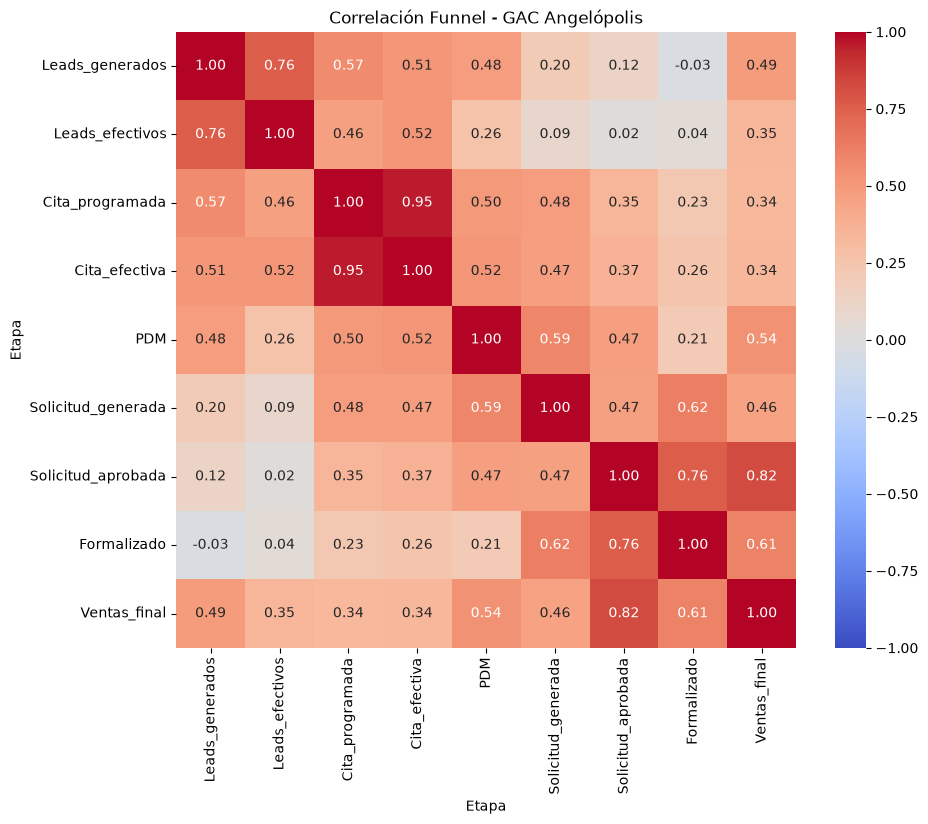

In [20]:
corr_gac = correlacion_canal(
    'GAC Angelopolis'
)

corr_gac

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_gac,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f'
)

plt.title(
    'Correlación Funnel - GAC Angelópolis'
)

plt.show()

In [21]:
corr_plaza = correlacion_canal(
    'Plaza Angelopolis'
)

corr_plaza

CANAL: Plaza Angelopolis
Observaciones: 18


Etapa,Leads_generados,Leads_efectivos,Cita_programada,Cita_efectiva,PDM,Solicitud_generada,Solicitud_aprobada,Formalizado,Ventas_final
Etapa,,,,,,,,,
Leads_generados,1.000,0.877,0.514,0.683,0.659,0.568,0.693,0.689,0.704
Leads_efectivos,0.877,1.000,0.357,0.402,0.474,0.308,0.509,0.534,0.505
Cita_programada,0.514,0.357,1.000,0.821,0.615,0.542,0.654,0.501,0.601
Cita_efectiva,0.683,0.402,0.821,1.000,0.794,0.761,0.818,0.646,0.816
PDM,0.659,0.474,0.615,0.794,1.000,0.573,0.736,0.729,0.797
Solicitud_generada,0.568,0.308,0.542,0.761,0.573,1.000,0.806,0.614,0.882
Solicitud_aprobada,0.693,0.509,0.654,0.818,0.736,0.806,1.000,0.866,0.881
Formalizado,0.689,0.534,0.501,0.646,0.729,0.614,0.866,1.000,0.781
Ventas_final,0.704,0.505,0.601,0.816,0.797,0.882,0.881,0.781,1.000


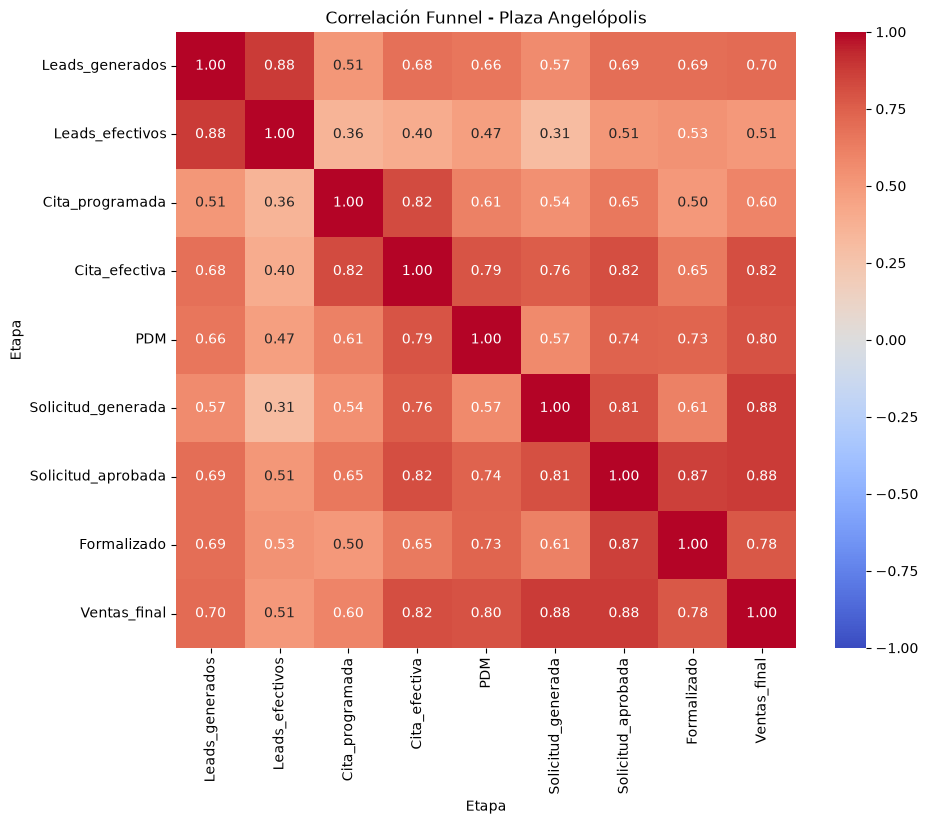

In [22]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_plaza,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f'
)

plt.title(
    'Correlación Funnel - Plaza Angelópolis'
)

plt.show()

In [23]:
corr_piso = correlacion_canal(
    'Piso'
)

corr_piso

CANAL: Piso
Observaciones: 18


Etapa,Leads_generados,Leads_efectivos,Cita_programada,Cita_efectiva,PDM,Solicitud_generada,Solicitud_aprobada,Formalizado,Ventas_final
Etapa,,,,,,,,,
Leads_generados,1.000,0.997,0.633,0.562,0.503,0.488,0.388,0.114,-0.457
Leads_efectivos,0.997,1.000,0.654,0.590,0.508,0.447,0.358,0.094,-0.472
Cita_programada,0.633,0.654,1.000,0.987,0.304,0.260,-0.025,-0.150,-0.503
Cita_efectiva,0.562,0.590,0.987,1.000,0.262,0.194,-0.095,-0.181,-0.519
PDM,0.503,0.508,0.304,0.262,1.000,0.191,0.216,-0.109,-0.198
Solicitud_generada,0.488,0.447,0.260,0.194,0.191,1.000,0.283,0.123,-0.202
Solicitud_aprobada,0.388,0.358,-0.025,-0.095,0.216,0.283,1.000,0.776,0.394
Formalizado,0.114,0.094,-0.150,-0.181,-0.109,0.123,0.776,1.000,0.386
Ventas_final,-0.457,-0.472,-0.503,-0.519,-0.198,-0.202,0.394,0.386,1.000


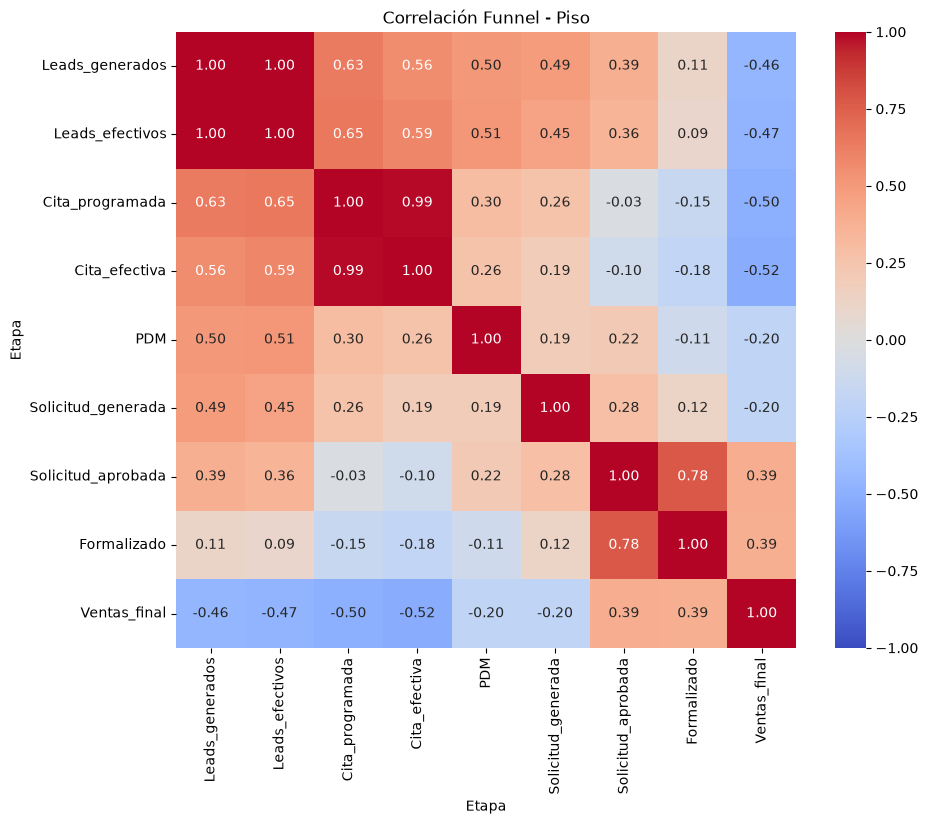

In [24]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_piso,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f'
)

plt.title(
    'Correlación Funnel - Piso'
)

plt.show()

CANAL: Digital
Observaciones: 18


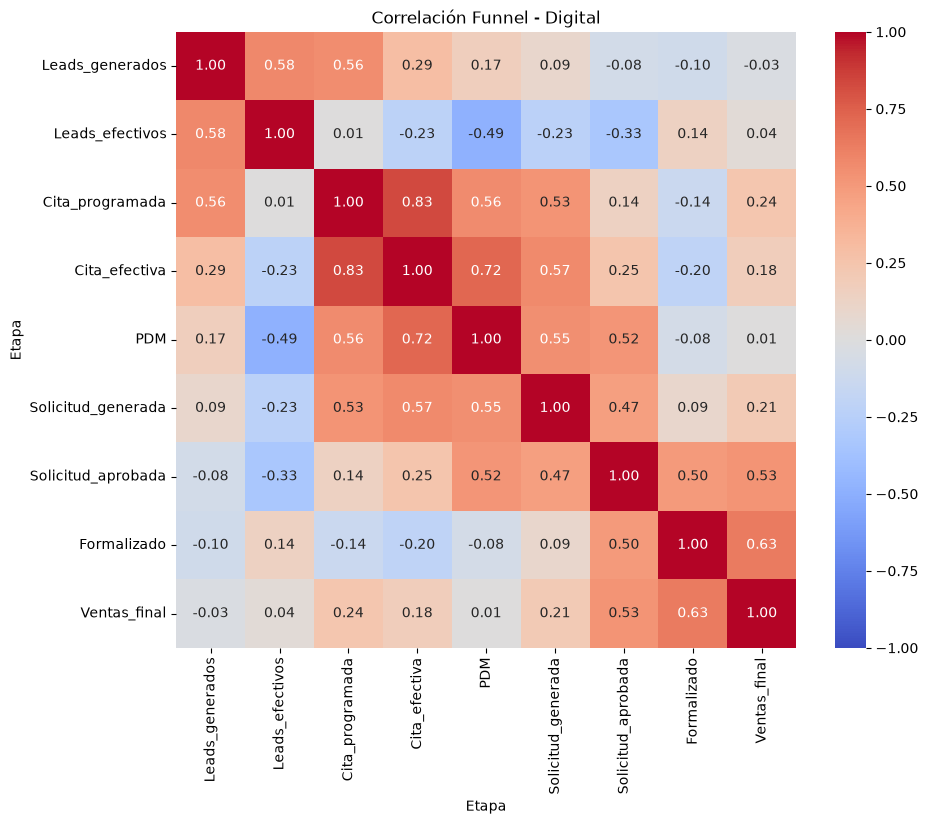

In [25]:
corr_digital = correlacion_canal(
    'Digital'
)

corr_digital

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_digital,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f'
)

plt.title(
    'Correlación Funnel - Digital'
)

plt.show()

In [26]:
canales_principales = [
    'GAC Angelopolis',
    'Plaza Angelopolis',
    'Piso',
    'Digital'
]

comparacion = []

for canal in canales_principales:

    datos = funnel[
        funnel['Canal_analisis'] == canal
    ].dropna(
        subset=[
            'Cita_programada',
            'Cita_efectiva'
        ]
    )

    r = datos[
        'Cita_programada'
    ].corr(
        datos['Cita_efectiva']
    )

    comparacion.append({
        'Canal': canal,
        'Observaciones': len(datos),
        'Correlacion': r
    })

comparacion_citas = pd.DataFrame(
    comparacion
)

comparacion_citas.round(3)

,Canal,Observaciones,Correlacion
0,GAC Angelopolis,18,0.955
1,Plaza Angelopolis,18,0.821
2,Piso,18,0.987
3,Digital,18,0.831


In [27]:
resultados_citas = []

modelos_citas = {}

for canal in canales_principales:

    datos = funnel[
        funnel['Canal_analisis'] == canal
    ].dropna(
        subset=[
            'Cita_programada',
            'Cita_efectiva'
        ]
    ).copy()

    X = datos[
        ['Cita_programada']
    ]

    y = datos[
        'Cita_efectiva'
    ]

    modelo = LinearRegression()

    modelo.fit(
        X,
        y
    )

    r = datos[
        'Cita_programada'
    ].corr(
        datos['Cita_efectiva']
    )

    resultados_citas.append({
        'Canal': canal,
        'Observaciones': len(datos),
        'Correlacion': r,
        'Pendiente': modelo.coef_[0],
        'Intercepto': modelo.intercept_,
        'R2': modelo.score(X, y)
    })

    modelos_citas[canal] = modelo

In [29]:
resultados_regresion_citas = pd.DataFrame(
    resultados_citas
)

resultados_regresion_citas.round(3)

,Canal,Observaciones,Correlacion,Pendiente,Intercepto,R2
0,GAC Angelopolis,18,0.955,0.740,0.496,0.912
1,Plaza Angelopolis,18,0.821,0.490,7.124,0.674
2,Piso,18,0.987,0.992,-1.380,0.974
3,Digital,18,0.831,0.530,1.754,0.690


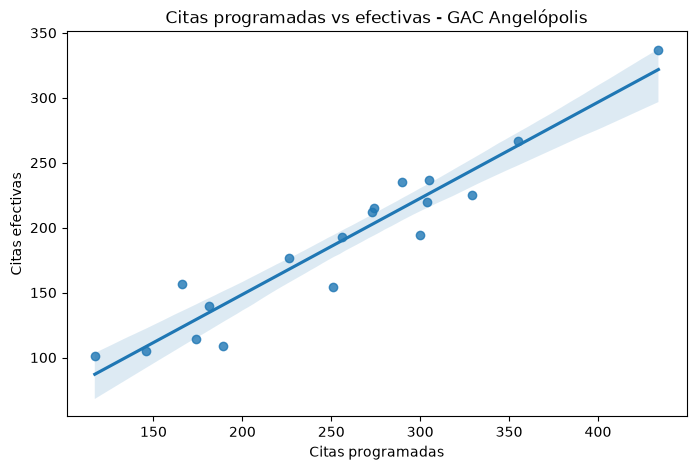

In [28]:
datos_gac = funnel[
    funnel['Canal_analisis']
    == 'GAC Angelopolis'
]

plt.figure(figsize=(8, 5))

sns.regplot(
    data=datos_gac,
    x='Cita_programada',
    y='Cita_efectiva'
)

plt.title(
    'Citas programadas vs efectivas - GAC Angelópolis'
)

plt.xlabel(
    'Citas programadas'
)

plt.ylabel(
    'Citas efectivas'
)

plt.show()

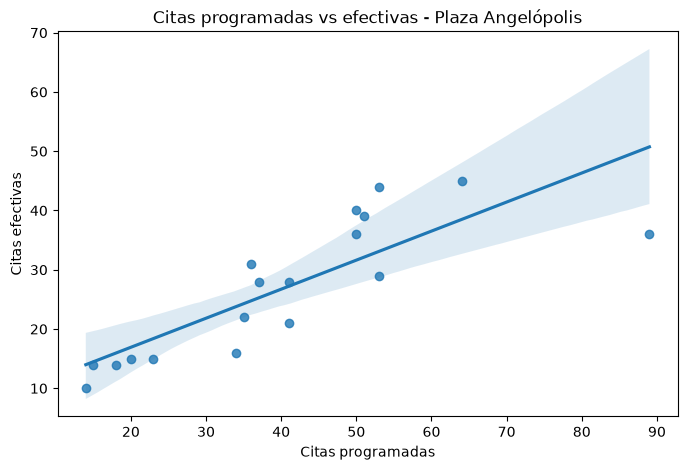

In [30]:
datos_plaza = funnel[
    funnel['Canal_analisis']
    == 'Plaza Angelopolis'
]

plt.figure(figsize=(8, 5))

sns.regplot(
    data=datos_plaza,
    x='Cita_programada',
    y='Cita_efectiva'
)

plt.title(
    'Citas programadas vs efectivas - Plaza Angelópolis'
)

plt.xlabel(
    'Citas programadas'
)

plt.ylabel(
    'Citas efectivas'
)

plt.show()

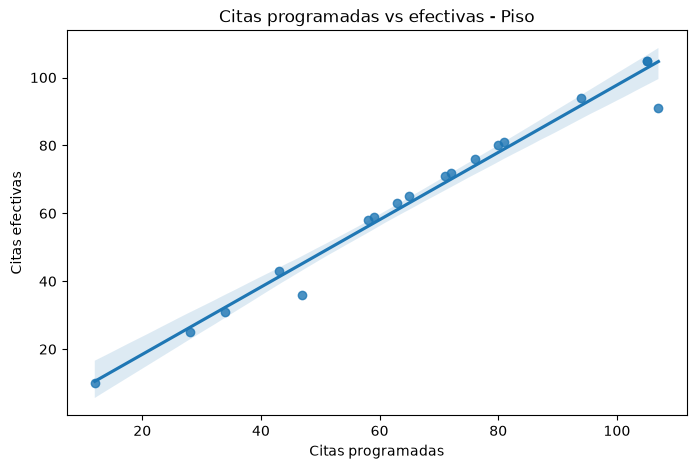

In [31]:
datos_piso = funnel[
    funnel['Canal_analisis']
    == 'Piso'
]

plt.figure(figsize=(8, 5))

sns.regplot(
    data=datos_piso,
    x='Cita_programada',
    y='Cita_efectiva'
)

plt.title(
    'Citas programadas vs efectivas - Piso'
)

plt.xlabel(
    'Citas programadas'
)

plt.ylabel(
    'Citas efectivas'
)

plt.show()

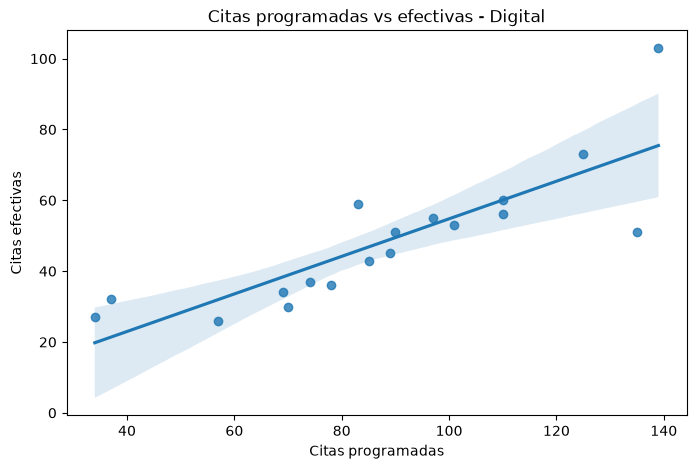

In [32]:
datos_digital = funnel[
    funnel['Canal_analisis']
    == 'Digital'
]

plt.figure(figsize=(8, 5))

sns.regplot(
    data=datos_digital,
    x='Cita_programada',
    y='Cita_efectiva'
)

plt.title(
    'Citas programadas vs efectivas - Digital'
)

plt.xlabel(
    'Citas programadas'
)

plt.ylabel(
    'Citas efectivas'
)

plt.show()

In [33]:
comparacion_leads_citas = []

for canal in canales_principales:

    datos = funnel[
        funnel['Canal_analisis'] == canal
    ].dropna(
        subset=[
            'Leads_efectivos',
            'Cita_programada'
        ]
    )

    r = datos[
        'Leads_efectivos'
    ].corr(
        datos['Cita_programada']
    )

    comparacion_leads_citas.append({
        'Canal': canal,
        'Observaciones': len(datos),
        'Correlacion': r
    })

comparacion_leads_citas = pd.DataFrame(
    comparacion_leads_citas
)

comparacion_leads_citas.round(3)

,Canal,Observaciones,Correlacion
0,GAC Angelopolis,18,0.461
1,Plaza Angelopolis,18,0.357
2,Piso,18,0.654
3,Digital,18,0.007


In [34]:
resultados_leads_citas = []

for canal in canales_principales:

    datos = funnel[
        funnel['Canal_analisis'] == canal
    ].dropna(
        subset=[
            'Leads_efectivos',
            'Cita_programada'
        ]
    ).copy()

    X = datos[
        ['Leads_efectivos']
    ]

    y = datos[
        'Cita_programada'
    ]

    modelo = LinearRegression()

    modelo.fit(
        X,
        y
    )

    r = datos[
        'Leads_efectivos'
    ].corr(
        datos['Cita_programada']
    )

    resultados_leads_citas.append({
        'Canal': canal,
        'Observaciones': len(datos),
        'Correlacion': r,
        'Pendiente': modelo.coef_[0],
        'Intercepto': modelo.intercept_,
        'R2': modelo.score(X, y)
    })


resultados_regresion_leads_citas = pd.DataFrame(
    resultados_leads_citas
)

resultados_regresion_leads_citas.round(3)

,Canal,Observaciones,Correlacion,Pendiente,Intercepto,R2
0,GAC Angelopolis,18,0.461,0.179,109.177,0.212
1,Plaza Angelopolis,18,0.357,0.145,13.992,0.127
2,Piso,18,0.654,0.950,-6.288,0.428
3,Digital,18,0.007,0.001,87.495,0.000


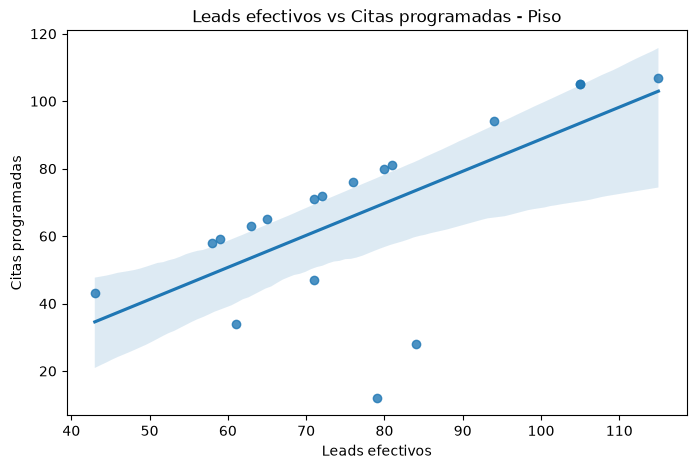

In [35]:
datos_piso = funnel[
    funnel['Canal_analisis'] == 'Piso'
]

plt.figure(figsize=(8, 5))

sns.regplot(
    data=datos_piso,
    x='Leads_efectivos',
    y='Cita_programada'
)

plt.title(
    'Leads efectivos vs Citas programadas - Piso'
)

plt.xlabel(
    'Leads efectivos'
)

plt.ylabel(
    'Citas programadas'
)

plt.show()

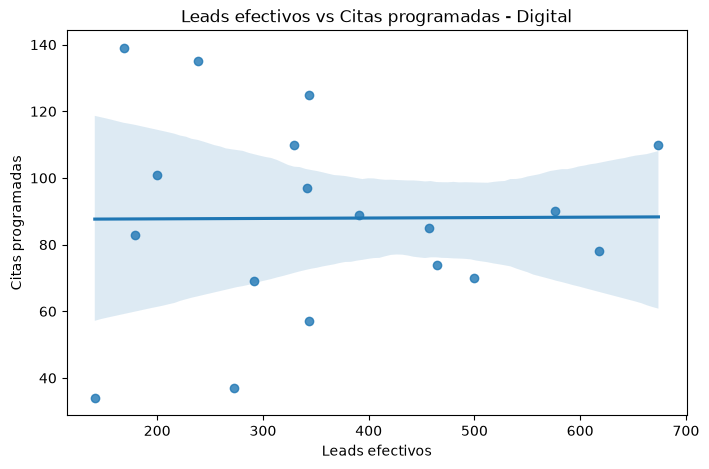

In [36]:
datos_digital = funnel[
    funnel['Canal_analisis'] == 'Digital'
]

plt.figure(figsize=(8, 5))

sns.regplot(
    data=datos_digital,
    x='Leads_efectivos',
    y='Cita_programada'
)

plt.title(
    'Leads efectivos vs Citas programadas - Digital'
)

plt.xlabel(
    'Leads efectivos'
)

plt.ylabel(
    'Citas programadas'
)

plt.show()

In [37]:
comparacion_solicitud_ventas = []

for canal in canales_principales:

    datos = funnel[
        funnel['Canal_analisis'] == canal
    ].dropna(
        subset=[
            'Solicitud_aprobada',
            'Ventas_final'
        ]
    )

    r = datos[
        'Solicitud_aprobada'
    ].corr(
        datos['Ventas_final']
    )

    comparacion_solicitud_ventas.append({
        'Canal': canal,
        'Observaciones': len(datos),
        'Correlacion': r
    })

comparacion_solicitud_ventas = pd.DataFrame(
    comparacion_solicitud_ventas
)

comparacion_solicitud_ventas.round(3)

,Canal,Observaciones,Correlacion
0,GAC Angelopolis,18,0.823
1,Plaza Angelopolis,18,0.881
2,Piso,18,0.394
3,Digital,18,0.527


In [38]:
resultados_solicitud_ventas = []

for canal in canales_principales:

    datos = funnel[
        funnel['Canal_analisis'] == canal
    ].dropna(
        subset=[
            'Solicitud_aprobada',
            'Ventas_final'
        ]
    ).copy()

    X = datos[
        ['Solicitud_aprobada']
    ]

    y = datos[
        'Ventas_final'
    ]

    modelo = LinearRegression()

    modelo.fit(
        X,
        y
    )

    r = datos[
        'Solicitud_aprobada'
    ].corr(
        datos['Ventas_final']
    )

    resultados_solicitud_ventas.append({
        'Canal': canal,
        'Observaciones': len(datos),
        'Correlacion': r,
        'Pendiente': modelo.coef_[0],
        'Intercepto': modelo.intercept_,
        'R2': modelo.score(X, y)
    })


resultados_regresion_solicitud_ventas = pd.DataFrame(
    resultados_solicitud_ventas
)

resultados_regresion_solicitud_ventas.round(3)

,Canal,Observaciones,Correlacion,Pendiente,Intercepto,R2
0,GAC Angelopolis,18,0.823,0.691,8.304,0.677
1,Plaza Angelopolis,18,0.881,0.942,-1.670,0.775
2,Piso,18,0.394,0.223,6.865,0.155
3,Digital,18,0.527,0.579,4.230,0.277


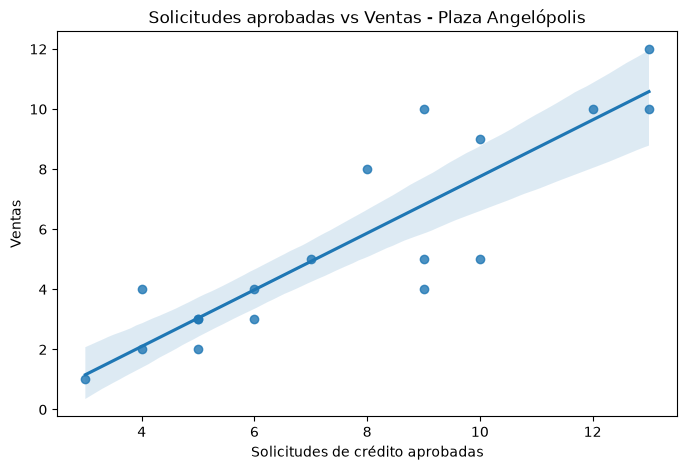

In [39]:
datos_plaza = funnel[
    funnel['Canal_analisis']
    == 'Plaza Angelopolis'
]

plt.figure(figsize=(8, 5))

sns.regplot(
    data=datos_plaza,
    x='Solicitud_aprobada',
    y='Ventas_final'
)

plt.title(
    'Solicitudes aprobadas vs Ventas - Plaza Angelópolis'
)

plt.xlabel(
    'Solicitudes de crédito aprobadas'
)

plt.ylabel(
    'Ventas'
)

plt.show()

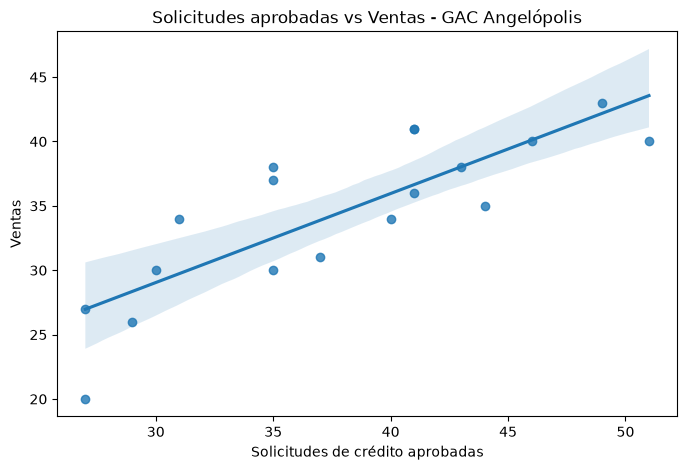

In [40]:
datos_gac = funnel[
    funnel['Canal_analisis']
    == 'GAC Angelopolis'
]

plt.figure(figsize=(8, 5))

sns.regplot(
    data=datos_gac,
    x='Solicitud_aprobada',
    y='Ventas_final'
)

plt.title(
    'Solicitudes aprobadas vs Ventas - GAC Angelópolis'
)

plt.xlabel(
    'Solicitudes de crédito aprobadas'
)

plt.ylabel(
    'Ventas'
)

plt.show()

In [41]:
comparacion_modelos_funnel = pd.concat([
    resultados_regresion_citas.assign(
        Relacion='Cita programada → Cita efectiva'
    ),

    resultados_regresion_leads_citas.assign(
        Relacion='Leads efectivos → Cita programada'
    ),

    resultados_regresion_solicitud_ventas.assign(
        Relacion='Solicitud aprobada → Ventas'
    )
], ignore_index=True)

comparacion_modelos_funnel = comparacion_modelos_funnel[
    [
        'Relacion',
        'Canal',
        'Observaciones',
        'Correlacion',
        'Pendiente',
        'Intercepto',
        'R2'
    ]
]

comparacion_modelos_funnel.round(3)

,Relacion,Canal,Observaciones,Correlacion,Pendiente,Intercepto,R2
0,Cita programada → Cita efectiva,GAC Angelopolis,18,0.955,0.740,0.496,0.912
1,Cita programada → Cita efectiva,Plaza Angelopolis,18,0.821,0.490,7.124,0.674
2,Cita programada → Cita efectiva,Piso,18,0.987,0.992,-1.380,0.974
3,Cita programada → Cita efectiva,Digital,18,0.831,0.530,1.754,0.690
4,Leads efectivos → Cita programada,GAC Angelopolis,18,0.461,0.179,109.177,0.212
5,Leads efectivos → Cita programada,Plaza Angelopolis,18,0.357,0.145,13.992,0.127
6,Leads efectivos → Cita programada,Piso,18,0.654,0.950,-6.288,0.428
7,Leads efectivos → Cita programada,Digital,18,0.007,0.001,87.495,0.000
8,Solicitud aprobada → Ventas,GAC Angelopolis,18,0.823,0.691,8.304,0.677
9,Solicitud aprobada → Ventas,Plaza Angelopolis,18,0.881,0.942,-1.670,0.775


In [42]:
comparacion_ordenada = (
    comparacion_modelos_funnel
    .sort_values(
        by='R2',
        ascending=False
    )
    .reset_index(drop=True)
)

comparacion_ordenada.round(3)

,Relacion,Canal,Observaciones,Correlacion,Pendiente,Intercepto,R2
0,Cita programada → Cita efectiva,Piso,18,0.987,0.992,-1.380,0.974
1,Cita programada → Cita efectiva,GAC Angelopolis,18,0.955,0.740,0.496,0.912
2,Solicitud aprobada → Ventas,Plaza Angelopolis,18,0.881,0.942,-1.670,0.775
3,Cita programada → Cita efectiva,Digital,18,0.831,0.530,1.754,0.690
4,Solicitud aprobada → Ventas,GAC Angelopolis,18,0.823,0.691,8.304,0.677
5,Cita programada → Cita efectiva,Plaza Angelopolis,18,0.821,0.490,7.124,0.674
6,Leads efectivos → Cita programada,Piso,18,0.654,0.950,-6.288,0.428
7,Solicitud aprobada → Ventas,Digital,18,0.527,0.579,4.230,0.277
8,Leads efectivos → Cita programada,GAC Angelopolis,18,0.461,0.179,109.177,0.212
9,Solicitud aprobada → Ventas,Piso,18,0.394,0.223,6.865,0.155


In [43]:
mejores_modelos_funnel = (
    comparacion_ordenada[
        comparacion_ordenada['R2'] >= 0.60
    ]
    .copy()
)

mejores_modelos_funnel.round(3)

,Relacion,Canal,Observaciones,Correlacion,Pendiente,Intercepto,R2
0,Cita programada → Cita efectiva,Piso,18,0.987,0.992,-1.380,0.974
1,Cita programada → Cita efectiva,GAC Angelopolis,18,0.955,0.740,0.496,0.912
2,Solicitud aprobada → Ventas,Plaza Angelopolis,18,0.881,0.942,-1.670,0.775
3,Cita programada → Cita efectiva,Digital,18,0.831,0.530,1.754,0.690
4,Solicitud aprobada → Ventas,GAC Angelopolis,18,0.823,0.691,8.304,0.677
5,Cita programada → Cita efectiva,Plaza Angelopolis,18,0.821,0.490,7.124,0.674
